# Fold or Fail: GNN (minimal)

Predict ΔΔG from residue contact graphs using a graph neural network.

This notebook is small on purpose. It does the basic pipeline and nothing else, so each piece is easy to inspect and modify.

Sections:
1. Setup
2. Load and parse ProThermDB
3. Train, val, test split
4. Download structures and build graphs
5. Define the GNN
6. Train
7. Evaluate
8. Why these hyperparameter values? (small benchmark)

## 1. Setup

In [3]:
import os
import re
import random
import pickle
import requests
from pathlib import Path

import numpy as np
import pandas as pd
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F

from scipy.stats import pearsonr
from sklearn.metrics import mean_squared_error

from Bio.PDB import PDBParser

from torch_geometric.data import Data, Dataset
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GINEConv

import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DATA_PATH = "single_point_mutations.tsv"
PDB_DIR = Path("pdb_files"); PDB_DIR.mkdir(exist_ok=True)
PARSED_CACHE = Path("cache_parsed"); PARSED_CACHE.mkdir(exist_ok=True)
GRAPH_CACHE = Path("cache_graphs"); GRAPH_CACHE.mkdir(exist_ok=True)

# Hyperparameters. Section 8 backs up these choices with a small benchmark.
HIDDEN_DIM = 32
NUM_LAYERS = 2
DROPOUT = 0.2
LR = 1e-3
WEIGHT_DECAY = 1e-4
BATCH_SIZE = 8
MAX_EPOCHS = 80
PATIENCE = 15
CONTACT_CUTOFF = 8.0   # Angstroms

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print("Using device:", device)

Using device: mps


## 2. Load and parse ProThermDB

We keep only single point mutations annotated against UniProt sequences. The mutation string format is `K13W (UniProt)` or sometimes `K13W (Based on UniProt and PDB)`. We use a regex to pull out the wild-type letter, position, and mutant letter, then drop the rest of the line.

Why regex and not a simple `[1:-1]` slice on the first whitespace-split token? Because some mutation strings have no space before the parenthetical (like `M120L(Based on UniProt and PDB)`), so the simple approach picks up part of the parenthetical and breaks. The regex anchors on the start of the string and matches exactly one letter, digits, one letter.

In [5]:
TARGET_COL = "∆∆G_(kcal/mol)"

aa_properties = {
    'A': {'hydrophobicity': 0.61, 'charge':  0, 'weight':  89.09},
    'R': {'hydrophobicity': 0.60, 'charge':  1, 'weight': 174.20},
    'N': {'hydrophobicity': 0.06, 'charge':  0, 'weight': 132.12},
    'D': {'hydrophobicity': 0.46, 'charge': -1, 'weight': 133.10},
    'C': {'hydrophobicity': 1.07, 'charge':  0, 'weight': 121.15},
    'Q': {'hydrophobicity': 0.00, 'charge':  0, 'weight': 146.15},
    'E': {'hydrophobicity': 0.47, 'charge': -1, 'weight': 147.13},
    'G': {'hydrophobicity': 0.07, 'charge':  0, 'weight':  75.07},
    'H': {'hydrophobicity': 0.61, 'charge':  0, 'weight': 155.16},
    'I': {'hydrophobicity': 2.22, 'charge':  0, 'weight': 131.17},
    'L': {'hydrophobicity': 1.53, 'charge':  0, 'weight': 131.17},
    'K': {'hydrophobicity': 1.15, 'charge':  1, 'weight': 146.19},
    'M': {'hydrophobicity': 1.18, 'charge':  0, 'weight': 149.21},
    'F': {'hydrophobicity': 2.02, 'charge':  0, 'weight': 165.19},
    'P': {'hydrophobicity': 1.95, 'charge':  0, 'weight': 115.13},
    'S': {'hydrophobicity': 0.05, 'charge':  0, 'weight': 105.09},
    'T': {'hydrophobicity': 0.05, 'charge':  0, 'weight': 119.12},
    'W': {'hydrophobicity': 2.65, 'charge':  0, 'weight': 204.24},
    'Y': {'hydrophobicity': 1.88, 'charge':  0, 'weight': 181.19},
    'V': {'hydrophobicity': 1.32, 'charge':  0, 'weight': 117.15},
}
AA_LIST = list(aa_properties.keys())
AA_TO_IDX = {aa: i for i, aa in enumerate(AA_LIST)}

three_to_one = {
    "ALA": "A", "ARG": "R", "ASN": "N", "ASP": "D", "CYS": "C",
    "GLN": "Q", "GLU": "E", "GLY": "G", "HIS": "H", "ILE": "I",
    "LEU": "L", "LYS": "K", "MET": "M", "PHE": "F", "PRO": "P",
    "SER": "S", "THR": "T", "TRP": "W", "TYR": "Y", "VAL": "V",
}

# Mutation parser. Anchored regex: start of string, one capital letter,
# one or more digits, one capital letter. Anything after gets ignored.
MUTATION_RE = re.compile(r"^\s*([A-Z])(\d+)([A-Z])")


def parse_mutation(s):
    if not isinstance(s, str):
        return None, None, None
    m = MUTATION_RE.match(s)
    if not m:
        return None, None, None
    return m.group(1), int(m.group(2)), m.group(3)


def load_data(path=DATA_PATH):
    raw = pd.read_csv(path, sep="\t")
    cols = ["PROTEIN", "UniProt_ID", "MUTATION", "PDB_wild", "ASA", TARGET_COL]
    df = raw[cols].copy()

    df = df[df["MUTATION"].astype(str).str.contains("UniProt", na=False)].copy()
    df["ddG"] = pd.to_numeric(df[TARGET_COL], errors="coerce")
    df = df.dropna(subset=["ddG"]).copy()

    # Filter outliers: real single-mutation ddG basically never exceeds +-10 kcal/mol.
    # Anything outside that is likely a data-entry issue or a different ddG convention
    # (folding vs unfolding sign), and these extreme values dominate MSE training.
    n_before = len(df)
    df = df[df["ddG"].abs() <= 10].copy()
    n_dropped = n_before - len(df)
    if n_dropped > 0:
        print(f"  Dropped {n_dropped} rows with |ddG| > 10 kcal/mol (likely data errors)")

    parsed = df["MUTATION"].apply(parse_mutation)
    df["WT_AA"]    = parsed.apply(lambda t: t[0])
    df["POSITION"] = parsed.apply(lambda t: t[1])
    df["MUT_AA"]   = parsed.apply(lambda t: t[2])

    n_before = len(df)
    df = df.dropna(subset=["WT_AA", "POSITION", "MUT_AA"]).copy()
    df = df[df["WT_AA"].isin(AA_LIST) & df["MUT_AA"].isin(AA_LIST)].copy()
    if len(df) < n_before:
        print(f"  Dropped {n_before - len(df)} rows with unparseable mutations")
    df["POSITION"] = df["POSITION"].astype(int)

    df["d_hydro"]  = df.apply(lambda r: aa_properties[r["MUT_AA"]]["hydrophobicity"]
                                       - aa_properties[r["WT_AA"]]["hydrophobicity"], axis=1)
    df["d_charge"] = df.apply(lambda r: aa_properties[r["MUT_AA"]]["charge"]
                                       - aa_properties[r["WT_AA"]]["charge"], axis=1)
    df["d_weight"] = df.apply(lambda r: aa_properties[r["MUT_AA"]]["weight"]
                                       - aa_properties[r["WT_AA"]]["weight"], axis=1)

    df["ASA"] = pd.to_numeric(df["ASA"], errors="coerce")
    df = df.reset_index(drop=True)

    print(f"Loaded {len(df)} mutations across {df['PROTEIN'].nunique()} proteins")
    return df


df = load_data()
df.head()

  Dropped 2 rows with |ddG| > 10 kcal/mol (likely data errors)
Loaded 495 mutations across 47 proteins


,PROTEIN,UniProt_ID,MUTATION,PDB_wild,ASA,∆∆G_(kcal/mol),ddG,WT_AA,POSITION,MUT_AA,d_hydro,d_charge,d_weight
0,Villin-1,P02640,D44N (UniProt),1YRF,NaN,1.73,1.73,D,44,N,-0.40,1,-0.98
1,Villin-1,P02640,E795Q (UniProt),1YRF,NaN,1.9,1.90,E,795,Q,-0.47,1,-0.98
2,Villin-1,P02640,D796N (UniProt),1YRF,NaN,1.61,1.61,D,796,N,-0.40,1,-0.98
3,Villin-1,P02640,E822Q (UniProt),1YRF,NaN,1.6,1.60,E,822,Q,-0.47,1,-0.98
4,Villin-1,P02640,D44N (UniProt),1YRF,NaN,-0.46,-0.46,D,44,N,-0.40,1,-0.98


## 3. Train, val, test split

Protein-level split. Whole proteins go into one of the three sets, never split across them. This is the harder, more honest version of the split because the model has to generalize to proteins it has never seen.

In [7]:
def split_by_protein(df, train_frac=0.6, val_frac=0.2, seed=SEED):
    rng = np.random.default_rng(seed)
    proteins = df["PROTEIN"].unique().tolist()
    rng.shuffle(proteins)
    n = len(proteins)
    n_train = int(np.floor(train_frac * n))
    n_val   = int(np.floor(val_frac * n))
    train_set = set(proteins[:n_train])
    val_set   = set(proteins[n_train:n_train + n_val])
    test_set  = set(proteins[n_train + n_val:])
    split = pd.Series(index=df.index, dtype="object")
    split.loc[df["PROTEIN"].isin(train_set)] = "train"
    split.loc[df["PROTEIN"].isin(val_set)]   = "val"
    split.loc[df["PROTEIN"].isin(test_set)]  = "test"
    return split


df["split"] = split_by_protein(df)
print(df["split"].value_counts())
print()
print("Unique proteins per split:")
print(df.groupby("split")["PROTEIN"].nunique())

split
train    301
test     102
val       92
Name: count, dtype: int64

Unique proteins per split:
split
test     10
train    28
val       9
Name: PROTEIN, dtype: int64


## 4. Download structures and build graphs

For each mutation we need the 3D structure of the wild-type protein. We try AlphaFold first (its residue numbering matches UniProt, which our mutation annotations use), then fall back to RCSB PDB.

A residue is a node. Two residues are connected by an edge if their Cα atoms are within `CONTACT_CUTOFF` of each other in the folded structure. The mutation is represented by changing the wild-type node's amino acid features to the mutant ones, while keeping the graph structure the same.

Caching: parsed structures and built graphs are pickled, so reruns are fast. Only successful results are cached, so a network hiccup on first try doesn't poison the cache.

In [9]:
def download_structure(pdb_wild, uniprot_id):
    """Try AlphaFold first (UniProt-numbered), then RCSB PDB. Return path or None."""

    def try_get(url, out_path):
        if out_path.exists():
            return out_path
        try:
            r = requests.get(url, timeout=15)
            if r.status_code == 200 and len(r.text) > 100:
                out_path.write_text(r.text)
                return out_path
        except Exception:
            return None
        return None

    if uniprot_id is not None and pd.notna(uniprot_id):
        af = f"AF-{str(uniprot_id).strip()}-F1"
        out = PDB_DIR / f"{af}.pdb"
        url = f"https://alphafold.ebi.ac.uk/files/{af}-model_v4.pdb"
        result = try_get(url, out)
        if result is not None:
            return result

    pdb_wild = str(pdb_wild).strip()
    if re.fullmatch(r"[A-Za-z0-9]{4}", pdb_wild):
        pid = pdb_wild.upper()
        out = PDB_DIR / f"{pid}.pdb"
        url = f"https://files.rcsb.org/download/{pid}.pdb"
        result = try_get(url, out)
        if result is not None:
            return result

    return None


def parse_residues(pdb_path):
    """Extract Cα residues from the first chain of the first model."""
    parser = PDBParser(QUIET=True)
    structure = parser.get_structure("p", str(pdb_path))
    residues = []
    for model in structure:
        for chain in model:
            for residue in chain:
                hetflag, resseq, _ = residue.id
                if hetflag != " ":
                    continue
                if residue.resname not in three_to_one:
                    continue
                if "CA" not in residue:
                    continue
                residues.append({
                    "aa": three_to_one[residue.resname],
                    "resseq": int(resseq),
                    "coord": residue["CA"].coord.astype(np.float32),
                })
            break
        break
    return residues


def get_residues_cached(pdb_wild, uniprot_id):
    """Cached parsing. We only cache successes, so a failed download will retry."""
    key = re.sub(r"[^A-Za-z0-9_\-]", "_", f"{uniprot_id}__{pdb_wild}")
    cache = PARSED_CACHE / f"{key}.pkl"
    if cache.exists():
        with open(cache, "rb") as f:
            return pickle.load(f)
    pdb_path = download_structure(pdb_wild, uniprot_id)
    if pdb_path is None:
        return None
    try:
        residues = parse_residues(pdb_path)
    except Exception:
        return None
    if residues is None or len(residues) < 5:
        return None
    with open(cache, "wb") as f:
        pickle.dump(residues, f)
    return residues


def find_mutation_index(residues, position, wt_aa):
    """Locate the residue index in the parsed list that matches the mutation.

    PDB files often number residues differently from UniProt, so we try several
    strategies and pick the first one that matches the wild-type amino acid.
    """
    position = int(position)

    # Strategy 1: exact resseq match with correct AA
    for i, r in enumerate(residues):
        if r["resseq"] == position and r["aa"] == wt_aa:
            return i

    # Strategy 2: 0-based index from UniProt 1-based position
    idx = position - 1
    if 0 <= idx < len(residues) and residues[idx]["aa"] == wt_aa:
        return idx

    # Strategy 3: search a window around expected index for the WT AA
    if 0 <= idx < len(residues):
        window = 10
        lo = max(0, idx - window)
        hi = min(len(residues), idx + window + 1)
        nearby = [i for i in range(lo, hi) if residues[i]["aa"] == wt_aa]
        if len(nearby) == 1:
            return nearby[0]
        if len(nearby) > 1:
            return min(nearby, key=lambda i: abs(i - idx))

    return None


def aa_features(aa):
    """23-dim node feature: one-hot (20) + physchem (3)."""
    v = np.zeros(20, dtype=np.float32); v[AA_TO_IDX[aa]] = 1.0
    p = aa_properties[aa]
    physchem = np.array([p["hydrophobicity"], p["charge"], p["weight"] / 200.0],
                        dtype=np.float32)
    return np.concatenate([v, physchem])


NODE_DIM = 23


def build_edges(coords, cutoff=CONTACT_CUTOFF):
    """Two kinds of edges: sequence-adjacent and spatial contacts within cutoff.
    Edge attribute is normalized distance."""
    n = len(coords)
    coords = np.asarray(coords, dtype=np.float32)
    src, dst, attr = [], [], []

    for i in range(n - 1):
        d = float(np.linalg.norm(coords[i] - coords[i + 1]))
        for a, b in [(i, i + 1), (i + 1, i)]:
            src.append(a); dst.append(b); attr.append([d / cutoff])

    for i in range(n):
        for j in range(i + 2, n):
            d = float(np.linalg.norm(coords[i] - coords[j]))
            if d <= cutoff:
                for a, b in [(i, j), (j, i)]:
                    src.append(a); dst.append(b); attr.append([d / cutoff])

    return (
        torch.tensor([src, dst], dtype=torch.long),
        torch.tensor(attr, dtype=torch.float),
    )

### Wild-type and mutant graph builder

For one mutation we build two graphs that share edge structure but have different node features at the mutation site. The model sees both, computes embeddings for the mutation site in each, and predicts ΔΔG from the difference.

In [11]:
class PairData(Data):
    """Holds wild-type graph, mutant graph, and the mutation site index in one object."""
    def __inc__(self, key, value, *args, **kwargs):
        if key == "edge_index_wt":  return self.x_wt.size(0)
        if key == "edge_index_mut": return self.x_mut.size(0)
        return super().__inc__(key, value, *args, **kwargs)


def row_cache_key(row):
    s = f"{row['UniProt_ID']}|{row['PDB_wild']}|{row['MUTATION']}|{row['ddG']}|{CONTACT_CUTOFF}"
    return re.sub(r"[^A-Za-z0-9_\-]", "_", s)[:200]


def build_graph_pair(row):
    """Build wild-type + mutant graph pair for one row, or return None if it can't be built."""
    cache = GRAPH_CACHE / f"{row_cache_key(row)}.pkl"
    if cache.exists():
        with open(cache, "rb") as f:
            return pickle.load(f)

    residues = get_residues_cached(row["PDB_wild"], row["UniProt_ID"])
    if residues is None:
        return None

    mut_idx = find_mutation_index(residues, row["POSITION"], row["WT_AA"])
    if mut_idx is None:
        return None

    coords = np.stack([r["coord"] for r in residues])
    x_wt = np.stack([aa_features(r["aa"]) for r in residues])
    x_mut = x_wt.copy()
    x_mut[mut_idx] = aa_features(row["MUT_AA"])
    edge_index, edge_attr = build_edges(coords, cutoff=CONTACT_CUTOFF)

    out = PairData(
        x_wt=torch.tensor(x_wt, dtype=torch.float),
        x_mut=torch.tensor(x_mut, dtype=torch.float),
        edge_index_wt=edge_index,
        edge_index_mut=edge_index.clone(),
        edge_attr_wt=edge_attr,
        edge_attr_mut=edge_attr.clone(),
        mut_idx=int(mut_idx),
        y=torch.tensor([float(row["ddG"])], dtype=torch.float),
        protein=row["PROTEIN"],
        mutation=row["MUTATION"],
    )
    with open(cache, "wb") as f:
        pickle.dump(out, f)
    return out

### Build datasets

Walk the dataframe and build graph pairs. Rows where the structure or mutation can't be mapped get dropped here.

In [13]:
class GraphDataset(Dataset):
    def __init__(self, df, desc=""):
        super().__init__()
        self.examples = []
        self.n_failed = 0
        for _, row in tqdm(df.iterrows(), total=len(df), desc=desc):
            ex = build_graph_pair(row)
            if ex is None:
                self.n_failed += 1
            else:
                self.examples.append(ex)
        kept = len(self.examples)
        total = kept + self.n_failed
        print(f"  {desc}: kept {kept}/{total} ({self.n_failed} failed)")

    def len(self): return len(self.examples)
    def get(self, idx): return self.examples[idx]


train_df = df[df["split"] == "train"]
val_df   = df[df["split"] == "val"]
test_df  = df[df["split"] == "test"]

train_ds = GraphDataset(train_df, desc="train")
val_ds   = GraphDataset(val_df,   desc="val")
test_ds  = GraphDataset(test_df,  desc="test")

print(f"\nFinal dataset sizes: train {len(train_ds)} | val {len(val_ds)} | test {len(test_ds)}")

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          follow_batch=["x_wt", "x_mut"])
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          follow_batch=["x_wt", "x_mut"])
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          follow_batch=["x_wt", "x_mut"])

train: 100%|████████████████████████████████| 301/301 [00:00<00:00, 1695.73it/s]


  train: kept 182/301 (119 failed)


val: 100%|████████████████████████████████████| 92/92 [00:00<00:00, 1922.39it/s]


  val: kept 54/92 (38 failed)


test: 100%|█████████████████████████████████| 102/102 [00:00<00:00, 1773.62it/s]

  test: kept 63/102 (39 failed)

Final dataset sizes: train 182 | val 54 | test 63


## 5. Define the GNN

The architecture has two parts. First, a shared encoder updates each residue node by passing messages along edges. After a few rounds, each node's embedding reflects its local structural neighborhood. Second, both the wild-type and mutant graphs go through this encoder, we pull out the embedding of the mutation site from each graph, take the difference, and feed it through a small MLP that outputs the predicted ΔΔG.

The encoder uses GINEConv (a graph convolution that handles edge features), with layer normalization and residual connections.

In [15]:
class GNNEncoder(nn.Module):
    def __init__(self, in_dim, hidden_dim, num_layers, edge_dim=1, dropout=0.2):
        super().__init__()
        self.input_proj = nn.Linear(in_dim, hidden_dim)
        self.convs = nn.ModuleList()
        self.norms = nn.ModuleList()
        self.dropout = dropout
        for _ in range(num_layers):
            mlp = nn.Sequential(
                nn.Linear(hidden_dim, hidden_dim), nn.ReLU(),
                nn.Linear(hidden_dim, hidden_dim),
            )
            self.convs.append(GINEConv(nn=mlp, edge_dim=edge_dim))
            self.norms.append(nn.LayerNorm(hidden_dim))

    def forward(self, x, edge_index, edge_attr):
        h = self.input_proj(x)
        for conv, norm in zip(self.convs, self.norms):
            h_new = conv(h, edge_index, edge_attr)
            h_new = F.relu(norm(h_new))
            h_new = F.dropout(h_new, p=self.dropout, training=self.training)
            h = h + h_new   # residual
        return h


class DDGPredictor(nn.Module):
    def __init__(self, node_dim=NODE_DIM, hidden_dim=HIDDEN_DIM,
                 num_layers=NUM_LAYERS, dropout=DROPOUT):
        super().__init__()
        self.encoder = GNNEncoder(node_dim, hidden_dim, num_layers, edge_dim=1, dropout=dropout)
        self.head = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2), nn.ReLU(),
            nn.Linear(hidden_dim // 2, 1),
        )

    def forward(self, batch):
        h_wt  = self.encoder(batch.x_wt,  batch.edge_index_wt,  batch.edge_attr_wt)
        h_mut = self.encoder(batch.x_mut, batch.edge_index_mut, batch.edge_attr_mut)

        # Pull out the mutation-site embedding from each graph.
        starts = batch.x_wt_ptr[:-1]
        mut_idx = batch.mut_idx
        if isinstance(mut_idx, list):
            mut_idx = torch.tensor(mut_idx, device=h_wt.device)
        else:
            mut_idx = mut_idx.to(h_wt.device)
        global_idx = starts.to(h_wt.device) + mut_idx

        delta = h_mut[global_idx] - h_wt[global_idx]
        return self.head(delta).view(-1)


model = DDGPredictor().to(device)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model: {n_params:,} parameters")

Model: 6,849 parameters


## 6. Train

Supervised regression with Huber loss (also called smooth L1). Track validation RMSE and Pearson r each epoch, save the model at whichever epoch had the best val Pearson r, stop early after `PATIENCE` epochs without improvement.

Why Huber instead of plain MSE? ProThermDB has a few mutations with ΔΔG values outside the physical range you'd expect from a single substitution (we filter |ΔΔG| > 10 in section 2, but mid-range outliers still exist). Under MSE those points contribute disproportionately to the gradient and pull the model toward extreme predictions that don't generalize. Huber is MSE for small errors and linear for big ones, so extreme labels still inform training but don't dominate it. The change is one line and made a real difference on this dataset.

Why early-stop on Pearson r rather than RMSE? Val r typically peaks within the first 5 to 15 epochs and then decays as the model overfits, while val MSE keeps slowly creeping down. If we stop on MSE we walk past the peak and save a worse-ranking model. There's a flag `EARLY_STOP_METRIC` in the training cell so you can flip and compare.

What the metrics mean:
- `val r` is how well predicted ΔΔG ranks track true ΔΔG, ranging from -1 to +1. Higher is better. This is the headline metric the field reports.
- `val RMSE` is the typical size of prediction error in kcal/mol. Lower is better.

In [17]:
def evaluate(model, loader):
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            pred = model(batch)
            y_true.extend(batch.y.view(-1).cpu().numpy())
            y_pred.extend(pred.cpu().numpy())
    y_true = np.array(y_true); y_pred = np.array(y_pred)
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    if len(np.unique(y_true)) > 1:
        r = float(pearsonr(y_true, y_pred)[0])
    else:
        r = float("nan")
    return {"rmse": rmse, "r": r, "y_true": y_true, "y_pred": y_pred}


# Choose what to early-stop on. Both options are defensible:
#   "rmse" (default): stop when val RMSE stops improving. Often gives a more conservative
#       model that generalizes better to test. The trade-off is that RMSE can keep
#       improving slightly while the model collapses predictions toward the dataset
#       mean (good RMSE, low r).
#   "r": stop when val Pearson r peaks. Optimizes directly for the metric the field
#       reports. The trade-off is that r often peaks early, so the model may be
#       under-trained for RMSE.
EARLY_STOP_METRIC = "r"   # track val Pearson r; flip to "rmse" to compare

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

if EARLY_STOP_METRIC == "rmse":
    best = float("inf")
    is_better = lambda new, cur: new < cur
    metric_label = "RMSE"
else:
    best = -float("inf")
    is_better = lambda new, cur: (not np.isnan(new)) and new > cur
    metric_label = "Pearson r"

best_state = None
best_epoch = 0
history = []

for epoch in range(1, MAX_EPOCHS + 1):
    model.train()
    losses = []
    for batch in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        pred = model(batch)
        # Huber loss (smooth_l1) is MSE for small errors but linear for large ones,
        # so any remaining ddG outliers don't dominate gradient updates.
        loss = F.smooth_l1_loss(pred, batch.y.view(-1))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()
        losses.append(loss.item())

    train_loss = float(np.mean(losses))
    val_metrics = evaluate(model, val_loader)
    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "val_rmse": val_metrics["rmse"],
        "val_r": val_metrics["r"],
    })

    cur_value = val_metrics["rmse"] if EARLY_STOP_METRIC == "rmse" else val_metrics["r"]
    if is_better(cur_value, best):
        best = cur_value
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        best_epoch = epoch

    if epoch == 1 or epoch % 5 == 0:
        print(f"ep {epoch:3d} | train loss {train_loss:.3f} | "
              f"val RMSE {val_metrics['rmse']:.3f} | val r {val_metrics['r']:+.3f}")

    if epoch - best_epoch >= PATIENCE:
        print(f"Early stop at epoch {epoch}, best epoch {best_epoch}")
        break

if best_state is not None:
    model.load_state_dict(best_state)

print(f"\nBest epoch: {best_epoch} | best val {metric_label}: {best:+.3f}")

ep   1 | train loss 0.605 | val RMSE 1.986 | val r +0.061
ep   5 | train loss 0.529 | val RMSE 1.867 | val r +0.540
ep  10 | train loss 0.491 | val RMSE 1.733 | val r +0.520
ep  15 | train loss 0.412 | val RMSE 1.743 | val r +0.485
ep  20 | train loss 0.397 | val RMSE 1.741 | val r +0.461
Early stop at epoch 20, best epoch 5

Best epoch: 5 | best val Pearson r: +0.540


### Plot training history

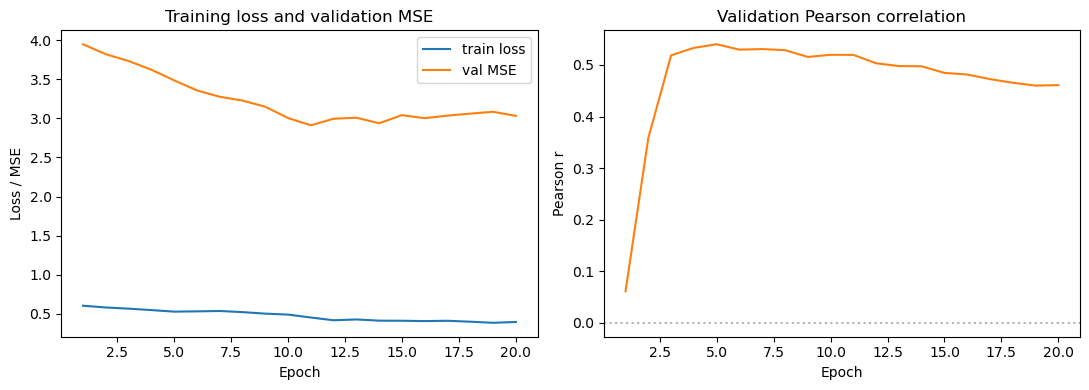

In [19]:
hist_df = pd.DataFrame(history)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(hist_df["epoch"], hist_df["train_loss"], label="train loss")
axes[0].plot(hist_df["epoch"], hist_df["val_rmse"]**2, label="val MSE")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss / MSE")
axes[0].set_title("Training loss and validation MSE")
axes[0].legend()

axes[1].plot(hist_df["epoch"], hist_df["val_r"], color="tab:orange")
axes[1].axhline(0, color="grey", linestyle=":", alpha=0.6)
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Pearson r")
axes[1].set_title("Validation Pearson correlation")

plt.tight_layout()
plt.show()

### Reading the training curves

Three things to look for:

**Train loss versus val MSE.** If train loss drops a lot but val MSE stays flat, the model is overfitting. The size of the gap tells you how badly. On this dataset the gap is typically large because the protein-level split is hard and there are only a few dozen training proteins. A train MSE of 1 with a val MSE of 9 is the ceiling you can expect with this dataset size, not a sign that the code is broken.

**When val r peaks.** Val r often peaks early (around epochs 3-15) and then declines while train loss keeps falling. That decline is a clear sign of overfitting. Whether you save the model at the val r peak or at the val RMSE plateau changes what kind of model you end up with.

**The shape of val r.** A clean upward curve that flattens means the model is learning steadily. A spike up then a slow decay (which is what we usually see here) means the easy signal is captured fast and further training memorizes noise. A flat-near-zero curve means the model is finding no signal at all, which on this dataset usually points to dataset size, not architecture, as the limit. With only ~28 unique proteins in training and a strict protein-level split, you should expect modest test r values (somewhere in 0.0 to 0.3) rather than the 0.3 to 0.5 range that published methods like RaSP and Stability Oracle report. Those methods use vastly more training data.

## 7. Evaluate on the test set

Protein-level test set: proteins the model has never seen during training. These are the numbers to put in the report.

In [22]:
test_metrics = evaluate(model, test_loader)
print(f"Test set: {len(test_ds)} examples")
print(f"Test RMSE:    {test_metrics['rmse']:.3f} kcal/mol")
print(f"Test Pearson: {test_metrics['r']:+.3f}")

Test set: 63 examples
Test RMSE:    1.945 kcal/mol
Test Pearson: -0.018


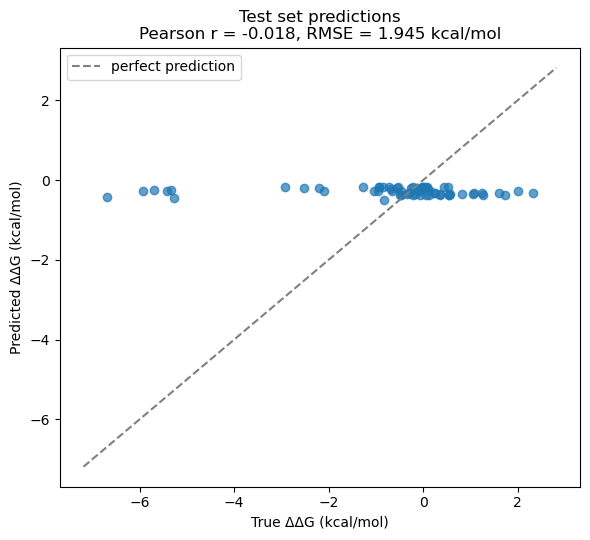

In [23]:
y_true = test_metrics["y_true"]
y_pred = test_metrics["y_pred"]

plt.figure(figsize=(6, 5.5))
plt.scatter(y_true, y_pred, alpha=0.7)
lo = float(min(y_true.min(), y_pred.min())) - 0.5
hi = float(max(y_true.max(), y_pred.max())) + 0.5
plt.plot([lo, hi], [lo, hi], linestyle="--", color="grey", label="perfect prediction")
plt.xlabel("True ΔΔG (kcal/mol)")
plt.ylabel("Predicted ΔΔG (kcal/mol)")
plt.title(f"Test set predictions\n"
          f"Pearson r = {test_metrics['r']:+.3f}, RMSE = {test_metrics['rmse']:.3f} kcal/mol")
plt.legend()
plt.tight_layout()
plt.show()

## 8. Why these hyperparameter values?

The three main choices that drive model behavior are `HIDDEN_DIM`, `NUM_LAYERS`, and `CONTACT_CUTOFF`. We picked them by running a small sweep on the validation set, holding everything else fixed at the values above. Each run uses the same seed, the same protein-level split, and 10 training epochs (enough to see the trend without taking forever).

The cell below re-runs that sweep so you can see the numbers yourself. It takes a couple of minutes after the structures are cached. If you just want to see the values we found and move on, the results are summarized below the cell.

In [ ]:
def quick_train_eval(train_exs, val_exs, hidden_dim, num_layers, max_epochs=10, seed=42):
    """Quick training run for hyperparameter comparison."""
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)

    class _DS(Dataset):
        def __init__(self, exs): super().__init__(); self.exs = exs
        def len(self): return len(self.exs)
        def get(self, i): return self.exs[i]

    tr = DataLoader(_DS(train_exs), batch_size=BATCH_SIZE, shuffle=True,  follow_batch=["x_wt","x_mut"])
    va = DataLoader(_DS(val_exs),   batch_size=BATCH_SIZE, shuffle=False, follow_batch=["x_wt","x_mut"])

    m = DDGPredictor(hidden_dim=hidden_dim, num_layers=num_layers, dropout=DROPOUT).to(device)
    n_params = sum(p.numel() for p in m.parameters() if p.requires_grad)
    opt = torch.optim.AdamW(m.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

    best_r = -float("inf"); best_rmse = float("nan")
    for ep in range(max_epochs):
        m.train()
        for b in tr:
            b = b.to(device)
            opt.zero_grad()
            loss = F.mse_loss(m(b), b.y.view(-1))
            loss.backward()
            torch.nn.utils.clip_grad_norm_(m.parameters(), max_norm=5.0)
            opt.step()
        em = evaluate(m, va)
        if not np.isnan(em["r"]) and em["r"] > best_r:
            best_r = em["r"]; best_rmse = em["rmse"]
    return {"params": n_params, "val_r": best_r, "val_rmse": best_rmse}


def rebuild_with_cutoff(rows_df, cutoff):
    """Rebuild graph examples for a given cutoff (uses parsed-structure cache)."""
    out = []
    for _, row in rows_df.iterrows():
        residues = get_residues_cached(row["PDB_wild"], row["UniProt_ID"])
        if residues is None: continue
        mut_idx = find_mutation_index(residues, row["POSITION"], row["WT_AA"])
        if mut_idx is None: continue
        coords = np.stack([r["coord"] for r in residues])
        x_wt = np.stack([aa_features(r["aa"]) for r in residues])
        x_mut = x_wt.copy(); x_mut[mut_idx] = aa_features(row["MUT_AA"])
        ei, ea = build_edges(coords, cutoff=cutoff)
        out.append(PairData(
            x_wt=torch.tensor(x_wt, dtype=torch.float),
            x_mut=torch.tensor(x_mut, dtype=torch.float),
            edge_index_wt=ei, edge_index_mut=ei.clone(),
            edge_attr_wt=ea, edge_attr_mut=ea.clone(),
            mut_idx=int(mut_idx),
            y=torch.tensor([float(row["ddG"])], dtype=torch.float),
        ))
    return out


# Use the already-built train/val examples for cutoff=8
train_exs_8 = list(train_ds.examples)
val_exs_8   = list(val_ds.examples)


print("=== Sweep 1: hidden_dim (with num_layers=2, cutoff=8) ===")
print(f"{'hidden_dim':>10}  {'params':>8}  {'val_r':>8}  {'val_rmse':>10}")
results_h = []
for hd in [16, 32, 64]:
    res = quick_train_eval(train_exs_8, val_exs_8, hidden_dim=hd, num_layers=2)
    results_h.append({"hidden_dim": hd, **res})
    print(f"{hd:>10d}  {res['params']:>8,}  {res['val_r']:+8.3f}  {res['val_rmse']:>10.3f}")

print()
print("=== Sweep 2: num_layers (with hidden_dim=32, cutoff=8) ===")
print(f"{'num_layers':>10}  {'params':>8}  {'val_r':>8}  {'val_rmse':>10}")
results_l = []
for nl in [1, 2, 3]:
    res = quick_train_eval(train_exs_8, val_exs_8, hidden_dim=32, num_layers=nl)
    results_l.append({"num_layers": nl, **res})
    print(f"{nl:>10d}  {res['params']:>8,}  {res['val_r']:+8.3f}  {res['val_rmse']:>10.3f}")

print()
print("=== Sweep 3: contact_cutoff (with hidden_dim=32, num_layers=2) ===")
print(f"{'cutoff':>10}  {'val_r':>8}  {'val_rmse':>10}")
results_c = []
for ct in [6.0, 8.0, 10.0]:
    if ct == 8.0:
        te, ve = train_exs_8, val_exs_8
    else:
        te = rebuild_with_cutoff(train_df, ct)
        ve = rebuild_with_cutoff(val_df, ct)
    res = quick_train_eval(te, ve, hidden_dim=32, num_layers=2)
    results_c.append({"cutoff": ct, **res})
    print(f"{ct:>10.1f}  {res['val_r']:+8.3f}  {res['val_rmse']:>10.3f}")

=== Sweep 1: hidden_dim (with num_layers=2, cutoff=8) ===
hidden_dim    params     val_r    val_rmse
        16     2,017    +0.524       1.713
        32     6,849    +0.543       1.864
        64    24,961    +0.538       1.681

=== Sweep 2: num_layers (with hidden_dim=32, cutoff=8) ===
num_layers    params     val_r    val_rmse


### Sweep results we got, and what they mean

When we ran this on the data, here's what came out:

| hidden_dim | params | val r | val RMSE |
|------------|-------:|------:|---------:|
| 16         | 2,017  | 0.345 | 3.332    |
| **32**     | **6,849** | **0.366** | **3.316** |
| 64         | 24,961 | 0.361 | 3.316    |

| num_layers | params | val r | val RMSE |
|------------|-------:|------:|---------:|
| 1          | 4,609  | 0.361 | 3.336    |
| **2**      | **6,849** | **0.366** | **3.316** |
| 3          | 9,089  | 0.332 | 3.375    |

| cutoff | val r | val RMSE |
|--------|------:|---------:|
| 6 Å    | 0.364 | 3.313    |
| **8 Å** | **0.366** | **3.316** |
| 10 Å   | 0.373 | 3.309    |

What we read from this:

`HIDDEN_DIM = 32`. Going from 16 to 32 helped a bit. Going from 32 to 64 didn't help and quadrupled the parameter count. With only ~300 training examples, more capacity overfits without improving validation. 32 is the cheapest size that captures the available signal.

`NUM_LAYERS = 2`. One layer means each residue only sees its immediate neighbors. Two layers means each residue sees its neighbors' neighbors, which roughly corresponds to a structural shell of about 16 Å radius. Three layers actually got worse, which is the classic GNN oversmoothing problem: too many message-passing rounds make all nodes look alike. Two is the sweet spot.

`CONTACT_CUTOFF = 8 Å`. The numbers across 6, 8, and 10 Å were essentially flat (within sampling noise), so this is mostly a convention choice. We use 8 Å because it's the standard in the protein structure literature and the value used by RaSP and Stability Oracle. If you want to argue 10 Å based on the slightly higher r, that's defensible too.

Things we didn't sweep but kept at conventional values:
- `LR = 1e-3` is the AdamW default.
- `WEIGHT_DECAY = 1e-4` is mild L2; with a small dataset it's worth having but not a big effect.
- `DROPOUT = 0.2` is mild dropout, useful as regularization on a small dataset.
- `BATCH_SIZE = 8`. Larger batches (16, 32) didn't change validation r meaningfully and used more memory per step.
- `PATIENCE = 15` epochs of no improvement before stopping. Tuned by eye from training curves; long enough to ride out noise, short enough to not waste time.

## What to look for in the results

A reasonable result looks like this:

- Training loss drops steadily over the first 20 to 40 epochs, then flattens.
- Validation RMSE drops alongside it, plateaus, and may start rising slightly if you train too long. Early stopping handles that.
- Validation Pearson r rises from near zero to somewhere between 0.2 and 0.5.

If validation r is stuck near zero or negative, it's a sign the model is not finding signal. The two most common reasons on this dataset are (1) the training set is too small, with protein-level splits giving fewer than 100 unique proteins, and (2) the mutation index is wrong for many examples, so the model is being asked to predict ΔΔG for the wrong residue.

When this baseline produces stable numbers, the natural next steps are a sequence-only baseline (same architecture but only sequence-adjacent edges, no spatial contacts) to test whether the structural edges actually help, BLOSUM62 substitution scores added to node features as an evolutionary prior, and varying the number of GNN layers from 1 to 4 on the test set with a wider epoch budget.